In [17]:
import numpy as np
import xml.etree.ElementTree as ET
from datetime import datetime, timezone
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
import scipy
import xarray as xr
from scripts import geometry, io

In [18]:
'''
Create SLC from S1 SAFE file:
par_S1_SLC data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/measurement/s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.tiff data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/annotation/s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.xml data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/annotation/calibration/calibration-s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.xml data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/annotation/calibration/noise-s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.xml  data/S1_data/desert/iw1_vv.slc.par data/S1_data/desert/iw1_vv.slc data/S1_data/desert/iw1_vv.slc.tops_par - - - 

Extract single burst:
ScanSAR_burst_copy  data/S1_data/desert/iw1_vv.slc data/S1_data/desert/iw1_vv.slc.par data/S1_data/desert/iw1_vv.slc.tops_par data/S1_data/desert/iw1_vv_burst1.slc data/S1_data/desert/iw1_vv_burst1.slc.par 1 - - -
'''

'\nCreate SLC from S1 SAFE file:\npar_S1_SLC data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/measurement/s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.tiff data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/annotation/s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.xml data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/annotation/calibration/calibration-s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.xml data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/annotation/calibration/noise-s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.xml  data/S1_data/desert/iw1_vv.slc.par data/S1_data/desert/iw1_vv.slc data/S1_data/desert/iw1_vv.slc.tops_par - - - \n\nExtract single burst:\nScanSAR_burst_copy  data/S1_data/desert/iw1_vv.slc data/S1_data/desert/iw1_vv.s

In [19]:
def iso_to_unix(iso_str: str) -> float:
    """
    Convert ISO8601 (no timezone) to unix seconds (assume UTC).
    Example: '2026-02-04T15:49:18.236719'
    """
    dt = datetime.fromisoformat(iso_str).replace(tzinfo=timezone.utc)
    
    return dt.timestamp()

def parse_slc_par(par_file):
    """
    Function to get parameters from GAMMA RS slc.par file into dictionary
    """
    params = {}
    with open(par_file, 'r') as f:
        for line in f:
            if ':' in line:
                key, _, val = line.partition(':')
                params[key.strip()] = val.strip().split()
    
    return params

def read_slc(slc_file, slc_par_file):
    """
    Function to read a GAMMA RS .slc file into an np.array image
    """
    par = parse_slc_par(slc_par_file)

    
    range_samples = int(par['range_samples'][0])
    azimuth_lines = int(par['azimuth_lines'][0])

    dt = np.dtype('>f4')
    raw = np.fromfile(slc_file, dtype=dt)
    complex_data = raw[0::2] + 1j * raw[1::2]

    return complex_data.reshape(azimuth_lines, range_samples)

def fft_doppler(SLC_PATH, SLC_PAR_PATH, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG):
    """
    Function to calculate the doppler centroids of an SLC image with FFT
    """

    slc = read_slc(SLC_PATH, SLC_PAR_PATH)
    dt_a = float(parse_slc_par(SLC_PAR_PATH)['azimuth_line_time'][0])

    n_rg = (slc.shape[1] - WIN_RG) // STRIDE_RG + 1
    n_az = (slc.shape[0] - WIN_AZ) // STRIDE_AZ + 1

    doppler_img = np.zeros((n_az*STRIDE_AZ, n_rg*STRIDE_RG))
    spectrum = np.empty((n_az,n_rg), dtype=object)

    freqs = np.fft.fftfreq(WIN_AZ, d=dt_a)
    freqs = np.fft.fftshift(freqs)

    for j in range(n_az):
        az_0 = j * STRIDE_AZ

        for i in range(n_rg):
            rg_0 = i * STRIDE_RG

            S = np.fft.fft(slc[az_0:az_0+WIN_AZ, rg_0:rg_0+WIN_RG], axis=0)
            S = np.fft.fftshift(S, axes=0) 
            S_abs = np.abs(S)**2
            P = np.sum(S_abs, axis=1)
            f_dc = np.sum(freqs * P) / np.sum(P)

            spectrum[j,i] = P
            doppler_img[j*STRIDE_AZ:(j+1)*STRIDE_AZ,i*STRIDE_RG:(i+1)*STRIDE_RG] = f_dc

    return doppler_img, freqs, spectrum

def CDE_doppler(SLC_PATH, SLC_PAR_PATH, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG):
    """
    Function to calculate the doppler centroids of an SLC image with CDE
    """
    slc = read_slc(SLC_PATH, SLC_PAR_PATH) 
    n_az = (slc.shape[0] - WIN_AZ) // STRIDE_AZ + 1
    n_rg = (slc.shape[1] - WIN_RG) // STRIDE_RG + 1

    dt_a = float(parse_slc_par(SLC_PAR_PATH)['azimuth_line_time'][0])
    F_az = 1.0 / dt_a

    doppler_img = np.zeros((n_az*STRIDE_AZ, n_rg*STRIDE_RG))

    for i in range(n_az):
        a0 = i * STRIDE_AZ
  
        for j in range(n_rg):
            r0 = j * STRIDE_RG

            patch = slc[a0:a0+WIN_AZ, r0:r0+WIN_RG]
            C = patch[1:, :] * np.conj(patch[:-1, :])
            R1 = np.mean(C)
            phi = np.angle(R1)
            
            test = -(F_az / (2.0*np.pi)) * phi
            doppler_img[i*STRIDE_AZ:(i+1)*STRIDE_AZ,j*STRIDE_RG:(j+1)*STRIDE_RG] = (F_az / (2.0*np.pi)) * phi

    return doppler_img

def get_dc_estimates(ANNOT_XML):
    """
    Function to get the doppler Parameters from BIOMASS annotation file.
    """
    dc_estimates = []
    root = ET.parse(ANNOT_XML).getroot()

    for dc in root.findall(".//dopplerParameters//dcEstimateList//dcEstimate"):
        az_iso = dc.findtext("azimuthTime")
        t0 = dc.findtext("t0")
        poly = dc.findtext("geometryDCPolynomial")

        if az_iso is None or t0 is None or poly is None:
            continue

        az_unix = iso_to_unix(az_iso)
        t0 = float(t0)
        coeffs = np.array([float(x) for x in poly.split()], dtype=np.float64)

        dc_estimates.append((az_unix, t0, coeffs))

    return dc_estimates

def estimate_geom_doppler(ANNOT_XML, doppler_img=None):
    """
    Estimates the Doppler effect induced by satellite geometry from doppler polynomials. If doppler centroid image of scene is given then geometry doppler is registered to the dc image.
    """
    root = ET.parse(ANNOT_XML).getroot()

    dc_estimates = get_dc_estimates(ANNOT_XML)

    slant_range_time_0 = float(root.findtext(".//firstSampleSlantRangeTime"))
    range_pixel_spacing = float(root.findtext(".//rangeTimeInterval"))
    n_samples = int(root.findtext(".//numberOfSamples"))
    n_lines = int(root.findtext(".//numberOfLines"))
    azimuth_time_0 = iso_to_unix(root.findtext(".//firstLineAzimuthTime"))
    azimuth_pixel_spacing = float(root.findtext(".//azimuthTimeInterval"))

    tau = slant_range_time_0 + np.arange(n_samples) * range_pixel_spacing

    if doppler_img is not None:
        geom_doppler_coregistered = np.full((n_lines, n_samples), 10000)

    geom_doppler = np.zeros((len(dc_estimates), tau.shape[0]))

    diff = dc_estimates[1][0] - dc_estimates[0][0]
    start_az_idx = 0
    check = False

    for i, entry in enumerate(dc_estimates):
        az_0 = entry[0]
        t0 = entry[1]
        c0, c1, c2, c3, c4 = entry[2]
        for j, t in enumerate(tau):
            geom_doppler[i, j] = c0 + c1 * (t-t0) + c2 * (t-t0)**2 + c3 * (t-t0)**3 + c4 * (t-t0)**4

        if doppler_img is not None:
            if np.abs(az_0 - azimuth_time_0) <= diff:
                check = True
            
            if check:
                az_idx = int((diff - (azimuth_time_0 - az_0)) // azimuth_pixel_spacing)
                geom_doppler_coregistered[start_az_idx:az_idx+1, :] = geom_doppler[i,:]
            
                start_az_idx = az_idx+1  

    if doppler_img is not None:
        geom_doppler_coregistered = geom_doppler_coregistered[0:doppler_img.shape[0], 0:doppler_img.shape[1]]

        return geom_doppler_coregistered
    
    else:
        return geom_doppler
        

In [20]:
# Windowing for CDE DC estimation
WIN_AZ = 186
WIN_RG = 256
STRIDE_AZ = 186
STRIDE_RG = 256

In [21]:
SLC_PATHS = []
SLC_PAR_PATHS = []

for i in range(1,10):
    SLC_PATHS.append(f"data/S1_data/desert/iw1_vv_burst{i}.slc")
    SLC_PAR_PATHS.append(f"data/S1_data/desert/iw1_vv_burst{i}.slc.par")

ANNOT_XML = "data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/annotation/s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.xml"

In [22]:
dc_img_ffts = []
freqs = []
spectrums = []
geoms=[]
dcas = []

for SLC_PATH, SLC_PAR_PATH in zip(SLC_PATHS, SLC_PAR_PATHS):
    dc_img_fft = fft_doppler(SLC_PATH, SLC_PAR_PATH, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG)[0]
    dc_img_ffts.append(dc_img_fft)
    freqs.append(fft_doppler(SLC_PATH, SLC_PAR_PATH, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG)[1])
    spectrums.append(fft_doppler(SLC_PATH, SLC_PAR_PATH, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG)[2])
    geom = geometry.estimate_geom_doppler_s1_burst(SLC_PAR_PATH, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG)
    geoms.append(geom)
    dcas.append(dc_img_fft-geom)

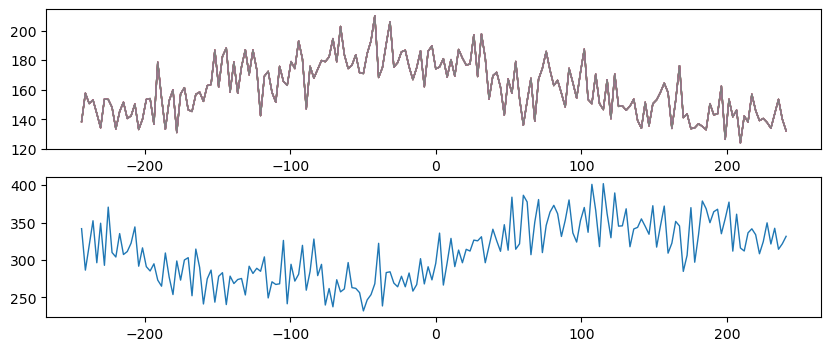

In [23]:
fig,ax = plt.subplots(2,1,figsize=(10,4))
for i in range(2,10):
    ax[0].plot(freqs[0], spectrums[0][1,13], lw=1)

for i in range(1):
    ax[1].plot(freqs[0], spectrums[0][i,1], lw=1)


In [24]:
dca = np.concatenate(dcas)

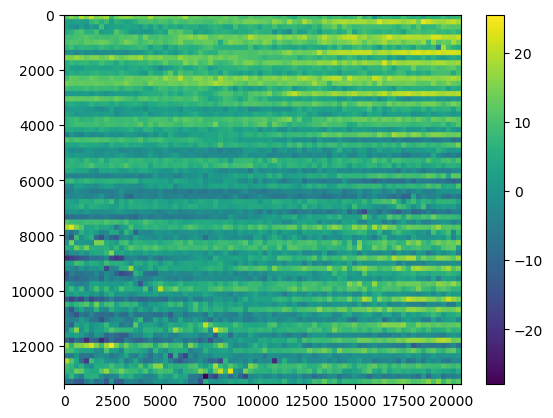

In [25]:
plt.imshow(dca, aspect='auto',)
plt.colorbar()

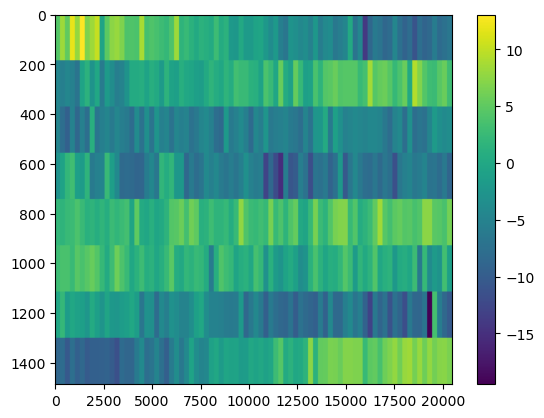

In [26]:
plt.imshow(dc_img_ffts[0], aspect='auto')
plt.colorbar()